In [1]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
import pandas as pd

import re, math
import numpy as np
import pandas as pd
from collections import Counter


In [2]:
df_reddit=pd.read_csv('reddit_goemotions_ekman.csv')
df_reddit.head()

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,...,goe_sum_active,goe_ekman_anger_prob,goe_ekman_disgust_prob,goe_ekman_fear_prob,goe_ekman_joy_prob,goe_ekman_sadness_prob,goe_ekman_surprise_prob,goe_ekman_neutral_prob,goe_ekman_top3,goe_ekman_dominant
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,...,1,0.217392,0.086691,0.006969,0.009748,0.071426,0.004082,0.032973,"[[""anger"", 0.21739214658737183], [""disgust"", 0...",anger
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,...,0,0.010493,0.002694,0.015703,0.029931,0.052743,0.089577,0.067588,"[[""surprise"", 0.08957719057798386], [""neutral""...",surprise
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,...,2,0.162279,0.010077,0.031708,0.003777,0.112582,0.061674,0.059673,"[[""anger"", 0.16227923333644867], [""sadness"", 0...",anger
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,...,2,0.037278,0.002749,0.011772,0.007008,0.172563,0.011487,0.223366,"[[""neutral"", 0.22336575388908386], [""sadness"",...",neutral
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,...,1,0.079917,0.012986,0.006537,0.039828,0.110959,0.016840,0.055468,"[[""sadness"", 0.11095861345529556], [""anger"", 0...",sadness


In [3]:
df_reddit.columns

Index(['Unnamed: 0', 'post_id', 'keyword', 'post_title', 'post_text',
       'post_date', 'comments', 'source_method', 'post_text_clean',
       'comments_clean', 'post_length', 'num_comments_length', 'year', 'month',
       'post_lemmas', 'comment_lemmas', 'post_title_lemmas', 'post_content',
       'sentiment', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'vader_sentiment', 'tb_polarity', 'tb_subjectivity', 'tb_sentiment',
       'otsu_class', 'jenks_class', 'gmm_class', 'goe_admiration_prob',
       'goe_admiration', 'goe_amusement_prob', 'goe_amusement',
       'goe_anger_prob', 'goe_anger', 'goe_annoyance_prob', 'goe_annoyance',
       'goe_approval_prob', 'goe_approval', 'goe_caring_prob', 'goe_caring',
       'goe_confusion_prob', 'goe_confusion', 'goe_curiosity_prob',
       'goe_curiosity', 'goe_desire_prob', 'goe_desire',
       'goe_disappointment_prob', 'goe_disappointment', 'goe_disapproval_prob',
       'goe_disapproval', 'goe_disgust_prob', 'goe_disgus

In [4]:
LEX_PATH="NRC-VAD-Lexicon-v2.1.txt"

In [5]:
from collections import defaultdict

# Recalculate V/A per post from scratch using a VAD lexicon
# - Single runnable cell. Uses existing df_reddit, LEX_PATH, pandas, numpy, re, math, etc.
# - Adds columns: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant,
#                 va_title_hits, va_body_hits, va_title_cov, va_body_cov
#
# Config / overrides:
MANUAL_OVERRIDES = {
    # example: 'battery': (0.5, 0.5),
    # put any token: (valence, arousal) in 0..1 here to force values
}
OUT_MODE = "clip"   # "clip" (default) or "halve"

# ---------- helpers ----------
negation_tokens = {"not","no","never","n't","cannot","neither","nor"}
intensifiers = {"very","really","so","extremely","highly","super","too","quite"}

def load_vad_norm(path):
    # robust loader: find word/valence/arousal columns, normalize to 0..1
    df = pd.read_csv(path, sep=None, engine="python")
    # normalize column names
    df.columns = [str(c).strip().lower() for c in df.columns]
    # pick word col
    word_col = next((c for c in df.columns if c in ("word","term","lemma")), None)
    # pick numeric cols
    val_col = next((c for c in df.columns if c in ("valence","v","val")), None)
    aro_col = next((c for c in df.columns if c in ("arousal","a","aro")), None)
    if word_col is None or val_col is None or aro_col is None:
        # try headerless with heuristics
        df2 = pd.read_csv(path, header=None, sep=None, engine="python")
        df2.columns = [f"col{i}" for i in range(df2.shape[1])]
        # token col: one with many non-numeric values
        word_col = next((c for c in df2.columns if pd.to_numeric(df2[c], errors="coerce").isna().mean() > 0.5), df2.columns[0])
        num_cols = [c for c in df2.columns if pd.to_numeric(df2[c], errors="coerce").notna().mean() > 0.9]
        if len(num_cols) < 2:
            raise RuntimeError("Could not detect V/A columns in lexicon.")
        val_col, aro_col = num_cols[0], num_cols[1]
        df = df2
    lex = df[[word_col, val_col, aro_col]].copy()
    lex.columns = ["word","val_raw","aro_raw"]
    lex["word"] = lex["word"].astype(str).str.lower().str.strip()
    lex["val_raw"] = pd.to_numeric(lex["val_raw"], errors="coerce")
    lex["aro_raw"] = pd.to_numeric(lex["aro_raw"], errors="coerce")
    lex = lex.dropna()
    vmin, vmax = float(lex["val_raw"].min()), float(lex["val_raw"].max())
    amin, amax = float(lex["aro_raw"].min()), float(lex["aro_raw"].max())
    # choose mapping based on ranges; keep 0..1 if already
    def normalize_series(smin, smax, arr):
        if smax <= 1.0 and smin >= 0.0:
            return arr.astype(float)  # already 0..1
        if smax > 1.5:
            # common cases: 1..9 -> map (x-1)/8 ; or -1..1 -> (x - min)/(max-min)
            if smin >= 1.0:
                return (arr - 1.0) / (smax - 1.0)
            if smin < 0.0 and abs(smin + 1.0) < 1e-2 and abs(smax - 1.0) < 1e-2:
                # typical -1..1
                return (arr + 1.0) / 2.0
            # fallback to min-max
            return (arr - smin) / max(1e-9, (smax - smin))
        else:
            # fallback normalize by min/max
            return (arr - smin) / max(1e-9, (smax - smin))
    lex["valence"] = normalize_series(vmin, vmax, lex["val_raw"])
    lex["arousal"] = normalize_series(amin, amax, lex["aro_raw"])
    vdict = dict(zip(lex["word"], lex["valence"].astype(float)))
    adict = dict(zip(lex["word"], lex["arousal"].astype(float)))
    return vdict, adict, lex

vdict, adict, lex_df = load_vad_norm(LEX_PATH)

# apply manual overrides into dicts (force tokens --> values)
for k, (vv, aa) in MANUAL_OVERRIDES.items():
    k2 = str(k).lower().strip()
    vdict[k2] = float(vv)
    adict[k2] = float(aa)

def tokenize_field(text):
    if not isinstance(text, str) or not text:
        return []
    # remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    # convert markdown links [label](url) -> label
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)
    # strip r/ and u/ prefixes -> keep the name
    text = re.sub(r"(?:u\/|r\/)([A-Za-z0-9_-]+)", r"\1", text)
    text = text.lower()
    # tokens: a-z with optional internal apostrophes
    toks = re.findall(r"[a-z][a-z']+", text)
    return toks

def clamp01(x):
    return max(0.0, min(1.0, float(x)))

def adjust_value_out_of_range(v, mode="clip"):
    # v expected in [-inf, +inf]; target [-1,1]
    if mode == "clip":
        return max(-1.0, min(1.0, float(v)))
    elif mode == "halve":
        # iteratively pull excess in half until within [-1,1]
        v = float(v)
        iter_guard = 0
        while abs(v) > 1.0 and iter_guard < 50:
            excess = abs(v) - 1.0
            v = (1.0 - 0.5 * excess) * (1.0 if v > 0 else -1.0)
            iter_guard += 1
        # final clamp to be safe
        return max(-1.0, min(1.0, v))
    else:
        raise ValueError("OUT_MODE must be 'clip' or 'halve'")

# ---------- pick fields ----------
body_col = next((c for c in ("selftext","body","text") if c in df_reddit.columns), None)
title_col = next((c for c in ("title","post_title") if c in df_reddit.columns), None)
if body_col is None and title_col is None:
    raise RuntimeError("No body/title columns found in df_reddit.")

# ---------- compute V/A per field ----------
def compute_field_scores(series_texts):
    """Return (val_series, aro_series, hits_series, coverage_series)
       - hits: number of lexicon-hit tokens (used for weighting)
       - coverage: percent tokens found (0..100)
    """
    vals = []
    aros = []
    hits = []
    covs = []
    for text in series_texts:
        toks = tokenize_field(text)
        if len(toks) == 0:
            vals.append(np.nan); aros.append(np.nan); hits.append(0); covs.append(0.0); continue
        v_sum = 0.0; a_sum = 0.0; count = 0
        total_tokens = len(toks)
        for i, tok in enumerate(toks):
            tok = tok.lower()
            # check manual override / lexicon
            if tok in MANUAL_OVERRIDES:
                base_v, base_a = MANUAL_OVERRIDES[tok]
            else:
                base_v = vdict.get(tok, None)
                base_a = adict.get(tok, None)
            if base_v is None or base_a is None:
                continue
            # look back up to 3 tokens for negation and intensifier
            start = max(0, i - 3)
            prev = toks[start:i]
            if any(p in negation_tokens for p in prev):
                base_v = 1.0 - base_v  # flip around 0.5
            if any(p in intensifiers for p in prev):
                base_v = 0.5 + 1.25 * (base_v - 0.5)
                base_a = 0.5 + 1.25 * (base_a - 0.5)
            base_v = clamp01(base_v)
            base_a = clamp01(base_a)
            v_sum += base_v
            a_sum += base_a
            count += 1
        if count > 0:
            vals.append(v_sum / count)
            aros.append(a_sum / count)
            hits.append(count)
            covs.append(100.0 * (count / total_tokens))
        else:
            vals.append(np.nan)
            aros.append(np.nan)
            hits.append(0)
            covs.append(0.0)
    return pd.Series(vals, index=series_texts.index, dtype="float32"), \
           pd.Series(aros, index=series_texts.index, dtype="float32"), \
           pd.Series(hits, index=series_texts.index, dtype="int32"), \
           pd.Series(covs, index=series_texts.index, dtype="float32")

# compute for title and body (if present)
title_vals = title_aros = title_hits = title_cov = None
body_vals = body_aros = body_hits = body_cov = None

if title_col is not None:
    title_vals, title_aros, title_hits, title_cov = compute_field_scores(df_reddit[title_col].fillna(""))
else:
    title_vals = pd.Series(np.nan, index=df_reddit.index, dtype="float32")
    title_aros = pd.Series(np.nan, index=df_reddit.index, dtype="float32")
    title_hits = pd.Series(0, index=df_reddit.index, dtype="int32")
    title_cov = pd.Series(0.0, index=df_reddit.index, dtype="float32")

if body_col is not None:
    body_vals, body_aros, body_hits, body_cov = compute_field_scores(df_reddit[body_col].fillna(""))
else:
    body_vals = pd.Series(np.nan, index=df_reddit.index, dtype="float32")
    body_aros = pd.Series(np.nan, index=df_reddit.index, dtype="float32")
    body_hits = pd.Series(0, index=df_reddit.index, dtype="int32")
    body_cov = pd.Series(0.0, index=df_reddit.index, dtype="float32")

# ---------- combine title + body into post-level V/A using token-count weighting ----------
va_val = []
va_aro = []
for i in df_reddit.index:
    vt, at = title_vals.loc[i], title_aros.loc[i]
    vb, ab = body_vals.loc[i], body_aros.loc[i]
    nt, nb = int(title_hits.loc[i]), int(body_hits.loc[i])
    # if both NaN/zero use NaN
    if (np.isnan(vt) or nt == 0) and (np.isnan(vb) or nb == 0):
        va_val.append(np.nan); va_aro.append(np.nan); continue
    # if one missing, use the other
    if (np.isnan(vt) or nt == 0) and (not np.isnan(vb) and nb > 0):
        va_val.append(float(vb)); va_aro.append(float(ab)); continue
    if (np.isnan(vb) or nb == 0) and (not np.isnan(vt) and nt > 0):
        va_val.append(float(vt)); va_aro.append(float(at)); continue
    # both present
    wsum = nt + nb
    v_comb = (vt * nt + vb * nb) / wsum
    a_comb = (at * nt + ab * nb) / wsum
    va_val.append(float(v_comb))
    va_aro.append(float(a_comb))

va_val = pd.Series(va_val, index=df_reddit.index, dtype="float32")
va_aro = pd.Series(va_aro, index=df_reddit.index, dtype="float32")

# ---------- map to circumplex and handle out-of-range ----------
va_val_std = 2.0 * va_val - 1.0
va_aro_std = 2.0 * va_aro - 1.0

# apply out-of-range handling per-element
va_val_std = va_val_std.apply(lambda x: np.nan if pd.isna(x) else adjust_value_out_of_range(x, OUT_MODE))
va_aro_std = va_aro_std.apply(lambda x: np.nan if pd.isna(x) else adjust_value_out_of_range(x, OUT_MODE))

# ---------- quadrant / center ----------
def quadrant_label(vs, ar):
    if pd.isna(vs) or pd.isna(ar):
        return None
    if abs(vs) < 0.1 and abs(ar) < 0.1:
        return "center"
    if vs >= 0 and ar >= 0:
        return "Q1"
    if vs < 0 and ar >= 0:
        return "Q2"
    if vs < 0 and ar < 0:
        return "Q3"
    if vs >= 0 and ar < 0:
        return "Q4"
    return None

va_quadrant = pd.Series([quadrant_label(vs, ar) for vs, ar in zip(va_val_std, va_aro_std)], index=df_reddit.index, dtype="object")

# ---------- attach columns to df_reddit ----------
df_reddit["va_valence"] = va_val
df_reddit["va_arousal"] = va_aro
df_reddit["va_val_std"] = va_val_std
df_reddit["va_aro_std"] = va_aro_std
df_reddit["va_quadrant"] = va_quadrant
df_reddit["va_title_hits"] = title_hits
df_reddit["va_body_hits"] = body_hits
df_reddit["va_title_cov"] = title_cov
df_reddit["va_body_cov"] = body_cov



# Quick summary prints
print("\nAdded columns to df_reddit: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant, va_title_hits, va_body_hits, va_title_cov, va_body_cov")
print(f"Fields used: title_col='{title_col}', body_col='{body_col}'")
print("OUT_MODE =", OUT_MODE)
# show a quick sample
display_cols = ["va_valence","va_arousal","va_val_std","va_aro_std","va_quadrant","va_title_hits","va_body_hits","va_title_cov","va_body_cov"]
print(df_reddit[display_cols].head(6))


Added columns to df_reddit: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant, va_title_hits, va_body_hits, va_title_cov, va_body_cov
Fields used: title_col='post_title', body_col='None'
OUT_MODE = clip
   va_valence  va_arousal  va_val_std  va_aro_std va_quadrant  va_title_hits  \
0    0.663250    0.470500    0.326500   -0.059000          Q4              4   
1    0.454281    0.434188   -0.091438   -0.131625          Q3             16   
2    0.505075    0.514225    0.010150    0.028450      center             20   
3    0.489731    0.507500   -0.020538    0.015000      center             13   
4    0.644000    0.433167    0.288000   -0.133667          Q4              3   
5    0.350667    0.758167   -0.298667    0.516333          Q2              3   

   va_body_hits  va_title_cov  va_body_cov  
0             0    100.000000          0.0  
1             0     94.117645          0.0  
2             0     80.000000          0.0  
3             0     86.666664          0.0  


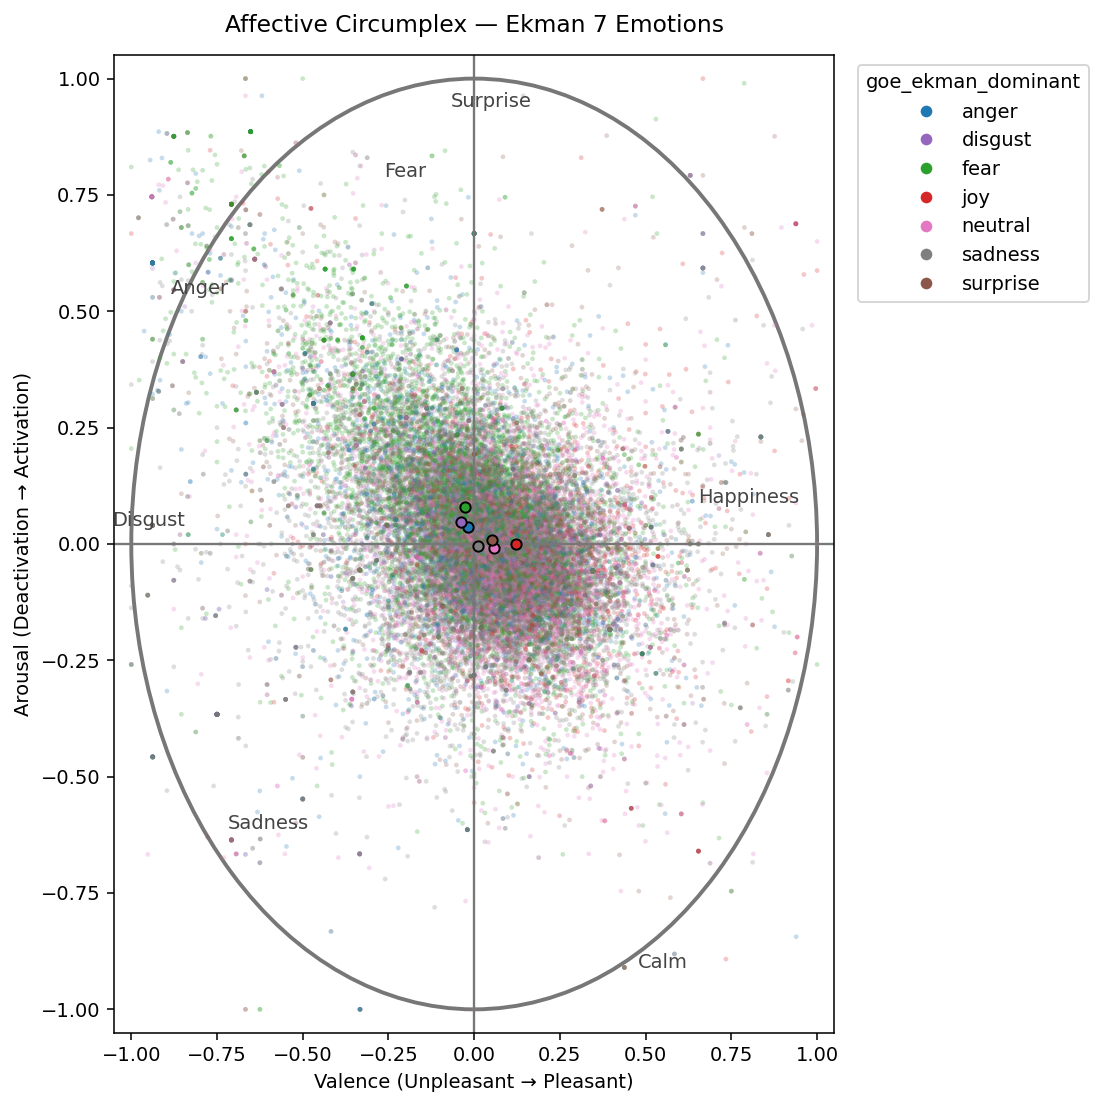

/var/folders/x7/xrth4_p955x331lrb98xvffh0000gn/T/ipykernel_38127/1537300341.py:127: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(8, len(unique_goe)))


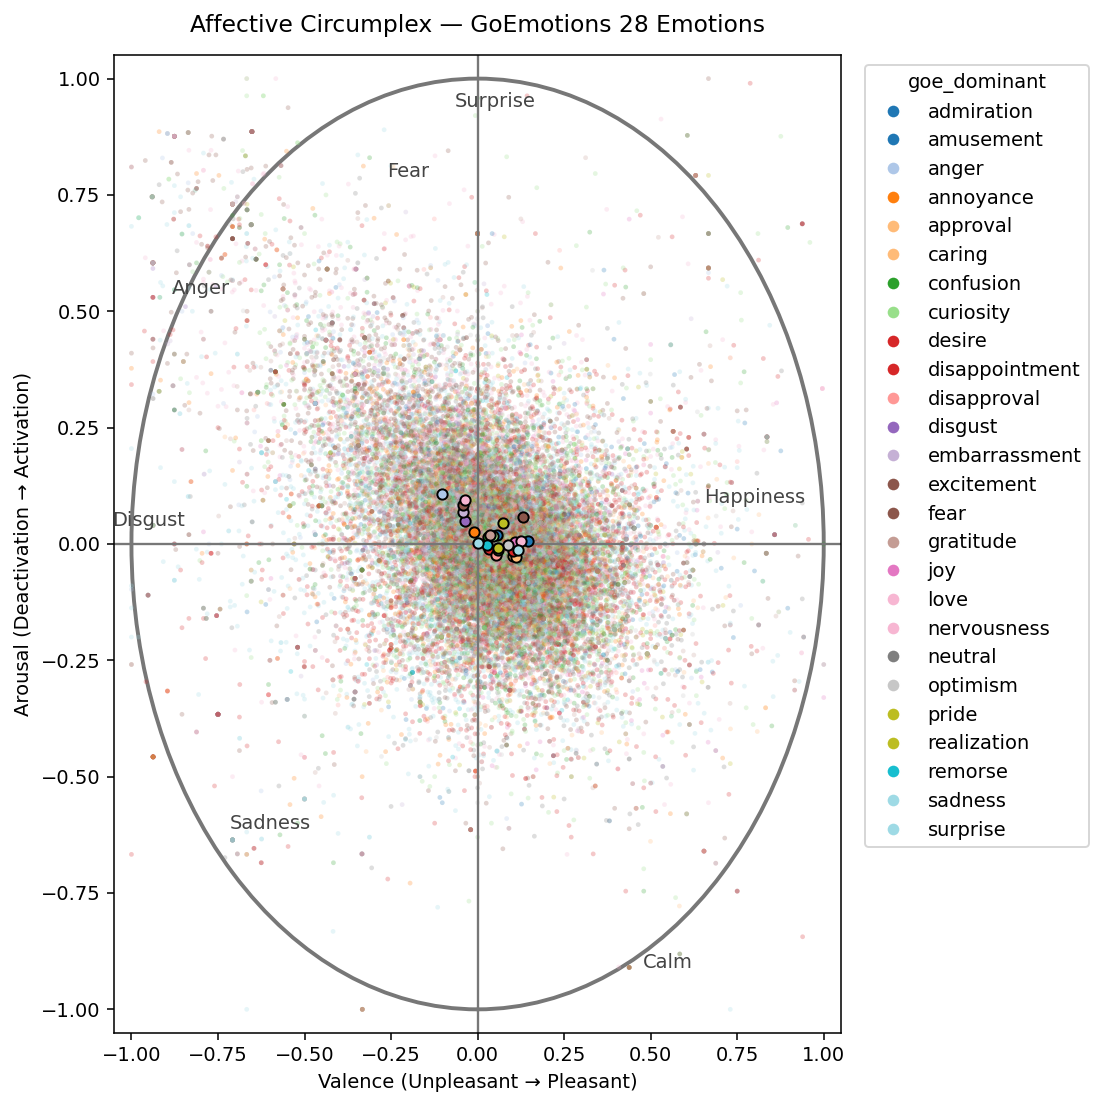


Ekman 7 — summary (sorted by n):
 Emotion    n  mean_val  mean_aro
    fear 7590    -0.028     0.080
 sadness 7370     0.011    -0.005
 neutral 6369     0.059    -0.009
surprise 4059     0.051     0.008
   anger 2969    -0.018     0.036
     joy 1386     0.121    -0.000
 disgust  257    -0.040     0.047

GoEmotions 28 — summary (sorted by n):
       Emotion    n  mean_val  mean_aro
       sadness 5294     0.001     0.002
     curiosity 3844     0.045     0.018
disappointment 3635     0.033    -0.010
          fear 3175    -0.043     0.083
   nervousness 2538    -0.035     0.095
       neutral 1996     0.058    -0.012
     confusion 1855     0.029     0.014
     annoyance 1488    -0.011     0.026
     gratitude  827     0.035     0.020
        desire  774     0.103    -0.016
   realization  544     0.060    -0.008
         anger  528    -0.102     0.108
          love  478     0.125     0.007
           joy  438     0.108     0.003
     amusement  437     0.057     0.019
      approval

In [6]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Config =====
VAL_COL = "va_val_std"
ARO_COL = "va_aro_std"
QUAD_COL = "va_quadrant"  # not shown on plot; used only for summaries
EKMAN_COL = "goe_ekman_dominant"
GOE_CANDIDATES = ["goe_dominant", "goe_emotion", "geo_ekman_dominant"]
MAX_N = 30000
RS = np.random.RandomState(42)

anchors = {
    "Happiness": (0.80, 0.10),
    "Calm":      (0.55,-0.90),
    "Sadness":   (-0.60,-0.60),
    "Anger":     (-0.80, 0.55),
    "Disgust":   (-0.95, 0.05),
    "Fear":      (-0.20, 0.80),
    "Surprise":  (0.05, 0.95),
}

ekman_palette = {
    "anger":   "#1f77b4",
    "disgust": "#9467bd",
    "fear":    "#2ca02c",
    "joy":     "#d62728",
    "sadness": "#7f7f7f",
    "surprise":"#8c564b",
    "neutral": "#e377c2",
}

def detect_goe_col(df):
    for c in GOE_CANDIDATES:
        if c in df.columns:
            return c
    return None

def prepare_sample(df, label_col):
    sub = df[[VAL_COL, ARO_COL, label_col]].dropna()
    if len(sub) > MAX_N:
        sub = sub.iloc[RS.choice(len(sub), size=MAX_N, replace=False)]
    return sub

def plot_circumplex_simple(df, label_col, title, palette=None):
    sub = prepare_sample(df, label_col)
    if sub.empty:
        print(f"No data for {label_col} — skipping.")
        return None, None

    labels = sub[label_col].astype(str).fillna("unknown")
    unique = labels.unique()

    # Colors
    if palette is None:
        cmap = plt.cm.get_cmap("tab20", max(8, len(unique)))
        color_map = {lab: cmap(i) for i, lab in enumerate(unique)}
    else:
        color_map = {lab: palette.get(str(lab).lower(), "#AAAAAA") for lab in unique}

    fig, ax = plt.subplots(figsize=(8, 8), dpi=140)

    # Single circumplex circle + axes
    circle = plt.Circle((0,0), 1.0, edgecolor="#777777", facecolor="none", lw=2)
    ax.add_artist(circle)
    ax.axhline(0, color="#777777", lw=1.2)
    ax.axvline(0, color="#777777", lw=1.2)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel("Valence (Unpleasant → Pleasant)")
    ax.set_ylabel("Arousal (Deactivation → Activation)")

    # Rim anchors (labels around the circle)
    for name, (px, py) in anchors.items():
        ax.text(px, py, name, fontsize=10, color="#444", ha="center", va="center")

    # Scatter
    cols = labels.map(lambda l: color_map.get(l, "#AAAAAA")).values
    ax.scatter(sub[VAL_COL], sub[ARO_COL], s=6, alpha=0.25, c=cols, edgecolors="none")

    # (Optional) small centroids — keep for orientation; remove if unwanted
    rows = []
    for lab, grp in sub.groupby(label_col):
        x = grp[VAL_COL].astype(float).values
        y = grp[ARO_COL].astype(float).values
        if len(x) == 0: 
            continue
        meanx, meany = float(np.mean(x)), float(np.mean(y))
        ax.scatter([meanx], [meany], s=28, color=color_map.get(lab, "#333333"), edgecolor="k", zorder=5)
        rows.append((lab, len(grp), meanx, meany))

    # Simple legend: emotions only (no quadrant or other text)
    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=color_map.get(lab,"#333333"),
                      markersize=7, label=str(lab)) for lab in sorted(unique)]
    ax.legend(handles=handles, title=label_col, bbox_to_anchor=(1.02, 1.0),
              loc="upper left", frameon=True)
    ax.set_title(title, pad=12)
    plt.tight_layout()

    summary = pd.DataFrame(rows, columns=["Emotion","n","mean_val","mean_aro"]).sort_values("n", ascending=False)
    return fig, summary

# ===== Ekman 7 =====
if EKMAN_COL in df_reddit.columns:
    ekman_sub = df_reddit[[VAL_COL, ARO_COL, EKMAN_COL]].dropna()
    if not ekman_sub.empty:
        fig1, summary_ekman = plot_circumplex_simple(df_reddit, EKMAN_COL,
                                                     "Affective Circumplex — Ekman 7 Emotions",
                                                     palette=ekman_palette)
        plt.show()
    else:
        print("No complete Ekman-labeled rows found.")
        summary_ekman = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])
else:
    print(f"Column '{EKMAN_COL}' not found; skipping Ekman plot.")
    summary_ekman = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])

# ===== GoEmotions 28 =====
goe_col = detect_goe_col(df_reddit)
if goe_col and goe_col in df_reddit.columns:
    goe_sub = df_reddit[[VAL_COL, ARO_COL, goe_col]].dropna()
    if not goe_sub.empty:
        unique_goe = np.unique(goe_sub[goe_col].astype(str))
        cmap = plt.cm.get_cmap("tab20", max(8, len(unique_goe)))
        palette_goe = {lab: cmap(i % cmap.N) for i, lab in enumerate(unique_goe)}
        fig2, summary_goe = plot_circumplex_simple(df_reddit, goe_col,
                                                   "Affective Circumplex — GoEmotions 28 Emotions",
                                                   palette=palette_goe)
        plt.show()
    else:
        print("No complete GoEmotions-labeled rows found.")
        summary_goe = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])
else:
    print("No GoEmotions label column detected; skipping GoEmotions plot.")
    summary_goe = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])

# ===== Print summaries (no quadrant text) =====
pd.set_option("display.max_rows", 200)
print("\nEkman 7 — summary (sorted by n):")
if not summary_ekman.empty:
    out_ek = summary_ekman.copy()
    out_ek["mean_val"] = out_ek["mean_val"].round(3)
    out_ek["mean_aro"] = out_ek["mean_aro"].round(3)
    print(out_ek.reset_index(drop=True).to_string(index=False))
else:
    print("No Ekman summary available.")

print("\nGoEmotions 28 — summary (sorted by n):")
if 'summary_goe' in locals() and not summary_goe.empty:
    out_goe = summary_goe.copy()
    out_goe["mean_val"] = out_goe["mean_val"].round(3)
    out_goe["mean_aro"] = out_goe["mean_aro"].round(3)
    print(out_goe.reset_index(drop=True).to_string(index=False))
else:
    print("No GoEmotions summary available.")


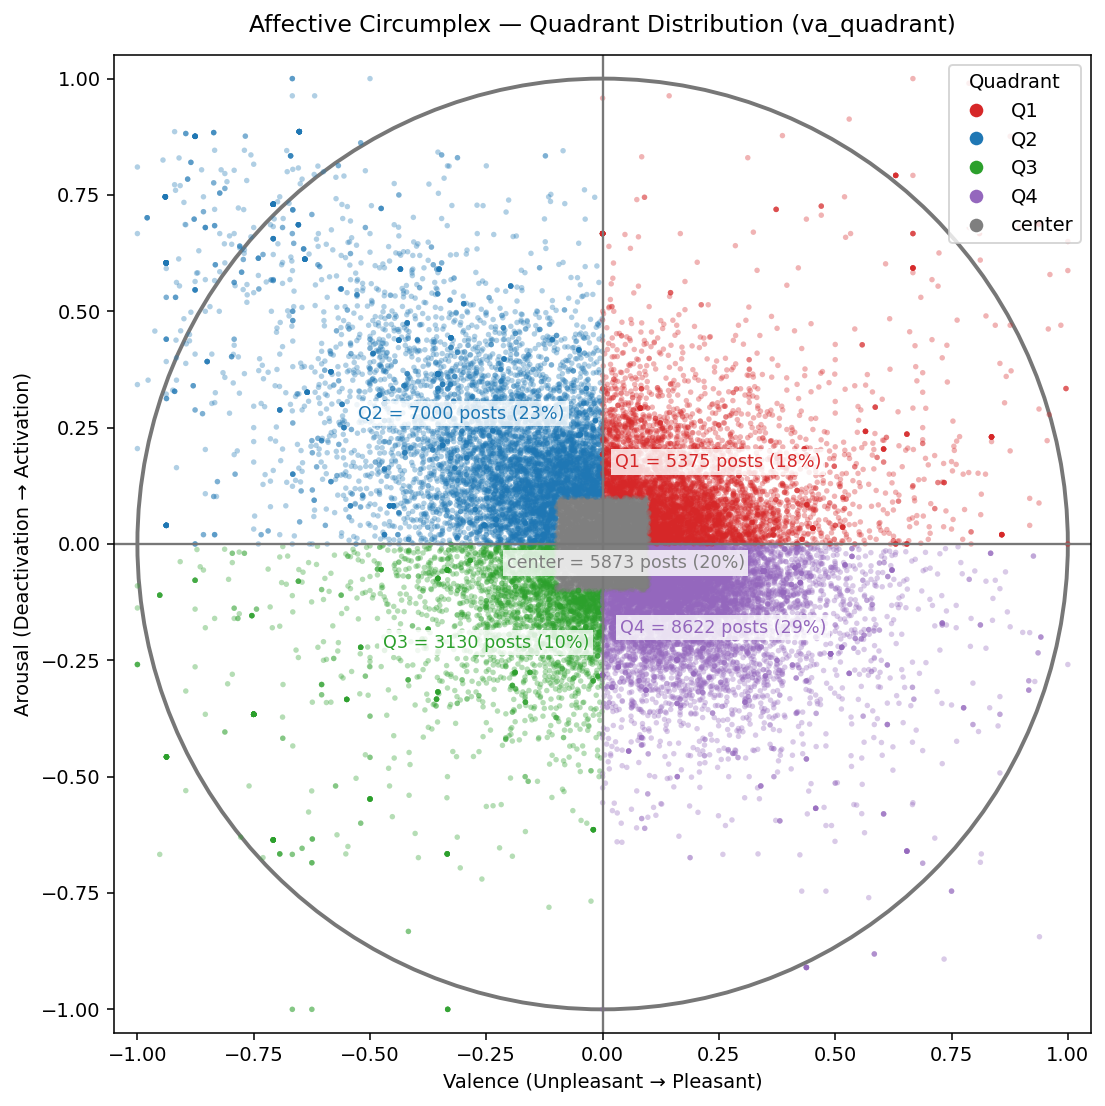

Quadrant    n  % of total  mean_valence  mean_arousal
      Q4 8622        28.7         0.218        -0.140
      Q2 7000        23.3        -0.263         0.240
  center 5873        19.6         0.009        -0.001
      Q1 5375        17.9         0.209         0.136
      Q3 3130        10.4        -0.210        -0.172


In [7]:
from matplotlib.lines import Line2D

# Quadrant-based circumplex visualization + summary (single cell)
# Uses existing variables: df_reddit, np, pd, plt

# 1) Prepare data: drop missing valence/arousal and require a quadrant label
df_q = df_reddit[["va_val_std", "va_aro_std", "va_quadrant"]].copy()
df_q = df_q.dropna(subset=["va_val_std", "va_aro_std"])
df_q = df_q[df_q["va_quadrant"].notna()].copy()

# 2) Subsample (<= 30000) with fixed seed
MAX_N = 30000
rng = np.random.RandomState(42)
if len(df_q) > MAX_N:
    df_q = df_q.sample(n=MAX_N, random_state=rng).reset_index(drop=True)

# 3) Color palette for quadrants
palette = {
    "Q1": "#d62728",      # red
    "Q2": "#1f77b4",      # blue
    "Q3": "#2ca02c",      # green
    "Q4": "#9467bd",      # purple
    "center": "#7f7f7f",  # gray
}
# If other spellings exist, try to normalise keys
df_q["va_quadrant"] = df_q["va_quadrant"].astype(str).map(lambda s: s.strip())

# 4) Plot setup
fig, ax = plt.subplots(figsize=(8, 8), dpi=140)

# Circle and cross-axes
circle = plt.Circle((0, 0), 1.0, edgecolor="#777777", facecolor="none", lw=2)
ax.add_artist(circle)
ax.axhline(0, color="#777777", lw=1.2)
ax.axvline(0, color="#777777", lw=1.2)

# 5) Scatter by quadrant
colors = df_q["va_quadrant"].map(lambda q: palette.get(q, "#AAAAAA"))
ax.scatter(df_q["va_val_std"], df_q["va_aro_std"], s=8, alpha=0.35, c=colors, edgecolors="none")

# 6) Compute per-quadrant stats
total = len(df_q)
grp = df_q.groupby("va_quadrant")[["va_val_std", "va_aro_std"]].agg(["count", "mean"])
# flatten columns
grp.columns = ["_".join(col).strip() for col in grp.columns.values]
summary = grp.reset_index().rename(columns={
    "va_val_std_count": "n",
    "va_val_std_mean": "mean_valence",
    "va_aro_std_mean": "mean_arousal"
})
summary["pct"] = (summary["n"] / total * 100.0).round(1)

# 7) Annotate centroids on plot
for _, row in summary.iterrows():
    q = row["va_quadrant"]
    mean_x = row["mean_valence"]
    mean_y = row["mean_arousal"]
    n = int(row["n"])
    pct = float(row["pct"])
    label_text = f"{q} = {n} posts ({int(round(pct))}%)"
    # offset annotations slightly from centroid for readability
    dx = 0.04 if mean_x >= 0 else -0.04
    dy = 0.04 if mean_y >= 0 else -0.04
    ax.text(mean_x + dx, mean_y + dy, label_text,
            fontsize=9, color=palette.get(q, "#333333"),
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
            ha="center", va="center")

# 8) Axes limits & labels & title
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Valence (Unpleasant → Pleasant)")
ax.set_ylabel("Arousal (Deactivation → Activation)")
ax.set_title("Affective Circumplex — Quadrant Distribution (va_quadrant)", pad=12)

# 9) Simple legend
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=8, label=lab)
           for lab, col in palette.items()]
ax.legend(handles=handles, title="Quadrant", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# 10) Print summary table sorted by count (descending)
out = summary[["va_quadrant", "n", "pct", "mean_valence", "mean_arousal"]].copy()
out = out.rename(columns={"va_quadrant": "Quadrant", "pct": "% of total"})
out["mean_valence"] = out["mean_valence"].round(3)
out["mean_arousal"] = out["mean_arousal"].round(3)
out = out.sort_values("n", ascending=False).reset_index(drop=True)
print(out.to_string(index=False))

In [8]:
df_reddit.head()

,Unnamed: 0,post_id,keyword,post_title,post_text,post_date,comments,source_method,post_text_clean,comments_clean,...,goe_ekman_dominant,va_valence,va_arousal,va_val_std,va_aro_std,va_quadrant,va_title_hits,va_body_hits,va_title_cov,va_body_cov
0,0,1dg7p5a,depression,I wish someone would just...,Just fucking kill me. Shoot me. I wish I could...,2024-06-15 11:54:16,['Life is overall shitty and borderline unbear...,top,fucking kill shoot wish bed fucking wake anymo...,life overall shitty borderline unbearable goin...,...,anger,0.663250,0.470500,0.326500,-0.059000,Q4,4,0,100.000000,0.0
1,1,1dga2ht,depression,A friend of mine once described depression as ...,And felt like that is the most apt description...,2024-06-15 14:12:57,['Whenever I was younger and when I was at my ...,top,felt apt description heard feels agree,younger lowest said home got older continued r...,...,surprise,0.454281,0.434188,-0.091438,-0.131625,Q3,16,0,94.117645,0.0
2,2,1f96hl3,depression,Therapist explained to me that normally people...,This has destroyed me. I’ve always thought may...,2024-09-05 07:54:46,['Sometimes I stew for HOURS on this. How are ...,top,destroyed thought maybe severely depressed tol...,stew hours constantly gutted life surprises re...,...,anger,0.505075,0.514225,0.010150,0.028450,center,20,0,80.000000,0.0
3,3,1g9mnuy,depression,"Everyone says if you're depressed, don't be af...","Well, we try to. And guess what? No one cares....",2024-10-23 03:11:27,"[""Thing is, even if someone did care, I do not...",top,try guess cares busy lives problems hear youre...,did care dump issues burden literally wont car...,...,neutral,0.489731,0.507500,-0.020538,0.015000,center,13,0,86.666664,0.0
4,4,1g5uwhx,depression,Quiet quitting life,I am quiet quitting life and nobody realizes t...,2024-10-18 02:56:16,['Man holy shit I’ve never related to somethin...,top,quiet quitting life realizes friends think bad...,man holy shit related life right doing years s...,...,sadness,0.644000,0.433167,0.288000,-0.133667,Q4,3,0,100.000000,0.0


In [9]:
# convert the df to csv
df_reddit.to_csv('reddit_circumplex_with_va.csv', index=False)